<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/TQQQ_VXN_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TQQQ Trading Strategy Backtesting with VXN Volatility Regimes

This notebook develops and backtests systematic trading strategies for TQQQ (ProShares UltraPro QQQ 3x Leveraged ETF) using the ^VXN (CBOE Nasdaq 100 Volatility Index) as a volatility filter. The backtest period runs from TQQQ's inception date (February 11, 2010) to the present, utilizing adjusted prices from `yfinance`.

## Project Goals:
1.  **Develop a VXN-Regime Allocation Strategy:** Implement a strategy that dynamically adjusts TQQQ allocation based on VXN volatility.
2.  **Develop a Dynamic Volatility Scalper:** Create a contrarian strategy that aggressively expands exposure during market panics.
3.  **Compare Performance:** Evaluate both strategies against a TQQQ Buy and Hold benchmark using key metrics like CAGR, Max Drawdown, and visual equity curves.

## Strategy 1: VXN-Regime Allocation Strategy
*   **Core Concept:** A fully vectorized strategy that uses a 5-day Simple Moving Average (SMA) of VXN to determine the percentage of the portfolio allocated to TQQQ.
*   **Mechanics:** TQQQ allocation is dynamically adjusted based on predefined VXN volatility regimes. Lower VXN (Regime 0 & 1) leads to higher allocation, while higher VXN (Regime 2 & 3) reduces or eliminates TQQQ exposure.

## Strategy 2: Dynamic Volatility Scalper ("Buy the Blood")
*   **Core Concept:** A contrarian framework designed to harvest short-term equity premiums by aggressively expanding exposure during market panics (high VXN) and capturing a quick structural rebound.
*   **Execution Structure:** Implemented as an explicit Daily Loop Simulation tracking discrete sub-portfolios or "lots" via an open list array (`buy_lots = []`), allowing specific lot-level entry, valuation updates, and profit targets.

### Key Parameters:
*   `MIN_ALLOC = 0.40`: The permanent exposure floor; the account is never fully in cash.
*   `MAX_ALLOC = 1.00`: Maximum allowable portfolio leverage.
*   `VXN_FLOOR = 18.18`: Volatility baseline below which only the minimum floor is held.
*   `VXN_CEILING = 60.0`: Extreme panic threshold forcing maximum exposure.

### Algorithmic Allocation Logic:
*   **Daily Revaluation:** Every day, all active lots in `buy_lots` are revalued based on the current day's `TQQQ_Return`. Total portfolio value is updated as `Cash + Sum(Active Lots)`.
*   **Profit-Target Exits:** Each individual lot is monitored independently. If a lot achieves a `+20%` return from its specific entry cost basis, it is liquidated completely, and its capital is returned to the cash balance.
*   **Continuous Target Sizing:** A dynamic target allocation percentage (`target_alloc_pct`) is calculated using linear interpolation based on the current day's VXN value between the `VXN_FLOOR` and `VXN_CEILING`.
*   **Deficit Processing:** If the actual current allocation percentage drops below the dynamic target, the script calculates the absolute dollar deficit and deploys available cash into a new discrete lot entry.
*   **Floor Enforcement:** If the final allocation still sits below `MIN_ALLOC` (due to massive cash inflows from liquidated winning lots), a forced entry lot is generated to pull the baseline exposure back to 40%.

## Strategy 3: Mean Reversion Strategy based on Logarithmic Trend
*   **Core Concept:** This strategy aims to profit from the tendency of TQQQ's price to revert to its long-term logarithmic trend. It identifies overbought and oversold conditions based on residuals from a linear regression of TQQQ's log price over time.
*   **Mechanics:** Uses Gaussian Mixture Models (GMM) to cluster the residuals into different regimes (e.g., most oversold, moderately oversold, moderately overbought, most overbought). Allocations to TQQQ are then dynamically adjusted based on these residual regimes, with higher allocations when TQQQ is oversold and lower/zero allocations when overbought.

## Benchmark: TQQQ Buy and Hold
*   **Core Concept:** A pure, passive buy-and-hold baseline to evaluate strategy outperformance (Alpha) and risk-adjusted return profiles.
*   **Mechanics:** Fully vectorized execution. 100% of capital is deployed into TQQQ on day one, compounding daily based on TQQQ's fractional percent changes.
*   **Historical Performance:** Historically (2010–2026), this benchmark compounds at a ~40% to 44% CAGR, but suffers an extreme maximum drawdown of ~81.6% during the 2022 market regime shift.

In [85]:
# Import necessary libraries
#import statements

import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display # Ensure display is available

In [86]:
# Clear all DataFrames from memory
import gc

# Get a list of all variables in the global namespace
all_vars = list(globals().keys())

# Identify and delete pandas DataFrames
for var_name in all_vars:
    if isinstance(globals()[var_name], pd.DataFrame):
        del globals()[var_name]
        print(f"Deleted DataFrame: {var_name}")

# Run garbage collector to free up memory
gc.collect()

print("All DataFrames cleared from memory.")

Deleted DataFrame: data
Deleted DataFrame: boundaries
Deleted DataFrame: regression_df
Deleted DataFrame: tqqq_analysis
Deleted DataFrame: simulation_df
Deleted DataFrame: X
Deleted DataFrame: boundaries_residuals
Deleted DataFrame: strategy_df
All DataFrames cleared from memory.


## Strategy 1: VXN-Regime Allocation Strategy

In [87]:
# Download data and discover VXN regimes using GMM
# 1. Download 20 years of VXN and TQQQ data
tickers = ["^VXN", "TQQQ"]
data = yf.download(tickers, start="2010-02-11", end="2026-01-01")['Close'].dropna()

# 2. Fit an unsupervised GMM to the raw VXN price to discover the 4 clusters
X_vxn = data['^VXN'].values.reshape(-1, 1)
gmm = GaussianMixture(n_components=4, random_state=42, covariance_type='full')
raw_labels = gmm.fit_predict(X_vxn)

# 3. Sort the discovered regimes strictly by VXN level so 0 is lowest, 3 is highest
idx = np.argsort(gmm.means_.flatten())
state_map = {old_label: new_label for new_label, old_label in enumerate(idx)}
data['Regime'] = [state_map[label] for label in raw_labels]

# 4. View the naturally discovered boundaries
boundaries = data.groupby('Regime')['^VXN'].agg(['min', 'max', 'mean', 'count'])
print("--- DISCOVERED REGIMES ---")
print(boundaries)

/tmp/ipykernel_4192/4252307258.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2010-02-11", end="2026-01-01")['Close'].dropna()
[*********************100%***********************]  2 of 2 completed

--- DISCOVERED REGIMES ---
          min        max       mean  count
Regime                                    
0       10.31  18.170000  15.615453   1590
1       18.18  24.080000  20.603574   1346
2       24.09  35.450001  28.790000    892
3       35.48  80.080002  41.089704    169


In [88]:
# Calculate TQQQ returns and create benchmark equity
# Calculate TQQQ daily simple returns to evaluate performance
data['TQQQ_Return'] = data['TQQQ'].pct_change()

# Create a copy for regression analysis and to serve as the consistent base for all strategies
regression_df = data.copy()

# Calculate Standard_Benchmark_Equity once here to be used across all strategies
initial_portfolio_value_benchmark = 100000.0
# Use fillna(1) for the first return to correctly initialize cumprod for the benchmark
regression_df['Standard_Benchmark_Equity'] = (1 + regression_df['TQQQ_Return']).fillna(1).cumprod() * initial_portfolio_value_benchmark

# Analyze TQQQ behavior inside each mathematically discovered regime
tqqq_analysis = data.groupby('Regime')['TQQQ_Return'].agg(['mean', 'std', 'count'])
# Annualize the returns and volatility for standard portfolio metrics
tqqq_analysis['Annualized_Return'] = tqqq_analysis['mean'] * 252
tqqq_analysis['Annualized_Vol'] = tqqq_analysis['std'] * np.sqrt(252)

print("\n--- TQQQ BEHAVIOR BY REGIME ---")
print(tqqq_analysis[['Annualized_Return', 'Annualized_Vol', 'count']])


--- TQQQ BEHAVIOR BY REGIME ---
        Annualized_Return  Annualized_Vol  count
Regime                                          
0                1.557305        0.330353   1590
1                0.606409        0.498236   1345
2               -0.155288        0.846344    892
3               -5.925937        1.358454    169


In [89]:
# Backtest VXN-Regime Allocation Strategy
# Use regression_df as the base for consistency across all strategy backtests
data = regression_df.copy()

# Ensure 'TQQQ_Daily_Return' is present, derived from the base data
# data['TQQQ_Daily_Return'] = data['TQQQ'].pct_change() # REMOVE this line
data['TQQQ_Daily_Return'] = data['TQQQ_Return'] # Use the already calculated return from regression_df
data['VXN_5_SMA'] = data['^VXN'].rolling(window=5).mean()
data = data.dropna().copy()

conditions = [
    (data['VXN_5_SMA'] < 18.18),
    (data['VXN_5_SMA'] >= 18.18) & (data['VXN_5_SMA'] < 24.09),
    (data['VXN_5_SMA'] >= 24.09)
]

MAX_ALLOCATION = 1
# Adjusted allocations to reflect the original strategy's intent if VXN < 24.09,
# and 0.0 for higher VXN. Re-check the original description for exact values.
# Based on the description 'Lower VXN (Regime 0 & 1) leads to higher allocation,
# while higher VXN (Regime 2 & 3) reduces or eliminates TQQQ exposure.' and previous code.
# Original code used: allocations = [MAX_ALLOCATION, MAX_ALLOCATION, 0.0]
allocations = [MAX_ALLOCATION, MAX_ALLOCATION, 0.0]

data['Target_Weight'] = np.select(conditions, allocations, default=0.0)
data['Allocated_Weight'] = data['Target_Weight'].shift(1)
data = data.dropna().copy()

data['Strategy_Daily_Return'] = data['Allocated_Weight'] * data['TQQQ_Daily_Return']

initial_portfolio_value = 100000.0
data['Strategy_Equity'] = (1 + data['Strategy_Daily_Return']).cumprod() * initial_portfolio_value

# Use the Standard_Benchmark_Equity from regression_df, reindexed to data's dates
data['Benchmark_Equity'] = regression_df['Standard_Benchmark_Equity'].reindex(data.index)

def calculate_metrics(return_series, equity_series, initial_value):
    total_return = (equity_series.iloc[-1] / initial_value - 1) * 100
    years = len(equity_series) / 252
    cagr = ((equity_series.iloc[-1] / initial_value) ** (1 / years) - 1) * 100
    ann_vol = return_series.std() * np.sqrt(252) * 100
    sharpe = cagr / ann_vol if ann_vol != 0 else 0

    rolling_max = equity_series.cummax()
    drawdowns = (equity_series - rolling_max) / rolling_max
    max_dd = drawdowns.min() * 100
    return cagr, ann_vol, sharpe, max_dd

# For benchmark calculation, we need to ensure the return series used for benchmark is consistent with the equity curve dates
bench_cagr, bench_vol, bench_sharpe, bench_mdd = calculate_metrics(data['TQQQ_Daily_Return'], data['Benchmark_Equity'], initial_portfolio_value)
strat_cagr, strat_vol, strat_sharpe, strat_mdd = calculate_metrics(data['Strategy_Daily_Return'], data['Strategy_Equity'], initial_portfolio_value)

final_strat_equity = data['Strategy_Equity'].iloc[-1]
final_bench_equity = data['Benchmark_Equity'].iloc[-1]

val_strat_str = f"${final_strat_equity:,.2f}"
val_bench_str = f"${final_bench_equity:,.2f}"
cagr_strat_str = f"{strat_cagr:.2f}%"
cagr_bench_str = f"{bench_cagr:.2f}%"
mdd_strat_str = f"{strat_mdd:.2f}%"
mdd_bench_str = f"{bench_mdd:.2f}%"

print(f"{'Metric':<25}{'VXN-Regime Strategy':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str:<25}{val_bench_str:<20}")
print(f"{'CAGR':<25}{cagr_strat_str:<25}{cagr_bench_str:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol:.2f}%':<25}{f'{bench_vol:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe:.2f}':<25}{f'{bench_sharpe:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str:<25}{mdd_bench_str:<20}")
print("-" * 70)

Metric                   VXN-Regime Strategy      TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $9,556,172.05            $25,543,139.23      
CAGR                     33.35%                   41.89%              
Annualized Vol           37.74%                   61.12%              
Sharpe Ratio             0.88                     0.69                
Max Drawdown             -49.11%                  -81.66%             
----------------------------------------------------------------------


### Strategy 1: VXN-Regime Allocation Strategy Equity Curve

This plot visualizes the performance of the VXN-Regime Allocation Strategy over the backtest period.

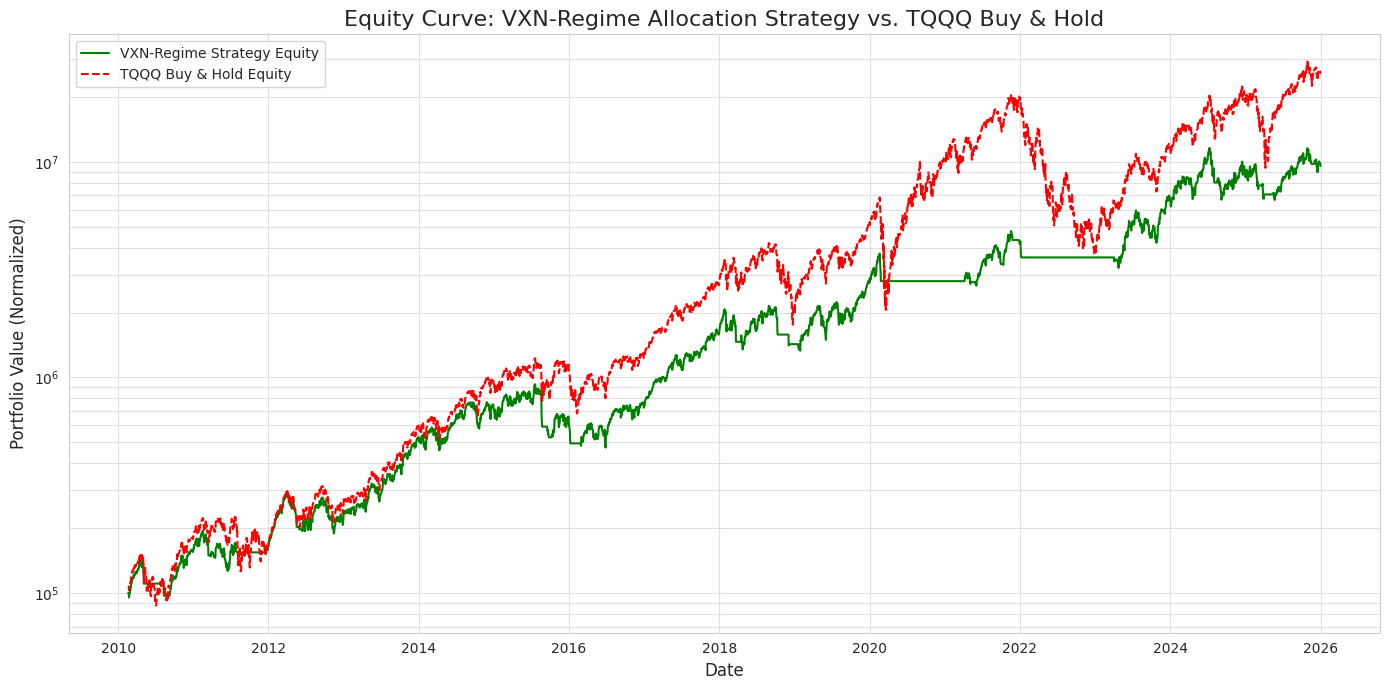

In [90]:
# Plot equity curve for VXN-Regime Allocation Strategy
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(data.index, data['Strategy_Equity'], label='VXN-Regime Strategy Equity', color='green')
plt.plot(data.index, data['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: VXN-Regime Allocation Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

### Strategy 2: Dynamic Volatility Scalper ("Buy the Blood") - Data Acquisition

This section fetches the historical price data for ^VXN and TQQQ using `yfinance` and prepares it for the backtesting process. Adjusted close prices are used to account for corporate actions, ensuring accurate historical pricing for both assets.

In [91]:
# Backtest Dynamic Volatility Scalper Strategy
# Use regression_df as the base for consistency across all strategy backtests
simulation_df = regression_df.copy()

# Ensure 'TQQQ_Return' is consistent
# simulation_df['TQQQ_Return'] = simulation_df['TQQQ'].pct_change() # REMOVE this line
simulation_df['TQQQ_Return'] = simulation_df['TQQQ_Return'] # Use the already calculated return from regression_df
simulation_df = simulation_df.dropna()

# 2. Simulation Variables (using values from the simulation_df)
portfolio_value = 100000.0  # Starting with $100k
cash = portfolio_value
buy_lots = []               # Tracking active lots
strategy_equity = []

MIN_ALLOC = 0.40
MAX_ALLOC = 1.00
VXN_FLOOR = 18.18
VXN_CEILING = 60.0

# 3. Corrected Daily Simulation Loop
for date, row in simulation_df.iterrows(): # Iterate over the consistent simulation_df
    vxn = row['^VXN']
    tqqq_price = row['TQQQ']
    tqqq_ret = row['TQQQ_Return']

    # Update valuation of held lots
    total_tqqq_value = 0.0
    for lot in buy_lots:
        lot['current_value'] = lot['current_value'] * (1 + tqqq_ret)
        total_tqqq_value += lot['current_value']

    portfolio_value = cash + total_tqqq_value

    # Check Exits (+20% profit target per lot)
    retained_lots = []
    for lot in buy_lots:
        current_gain = (lot['current_value'] / lot['allocated_cash']) - 1.0
        if current_gain >= 0.20:
            cash += lot['current_value']
        else:
            retained_lots.append(lot)

    buy_lots = retained_lots
    total_tqqq_value = sum(lot['current_value'] for lot in buy_lots)
    current_alloc_pct = total_tqqq_value / portfolio_value

    # Continuous Target Curve
    if vxn <= VXN_FLOOR:
        target_alloc_pct = MIN_ALLOC
    elif vxn >= VXN_CEILING:
        target_alloc_pct = MAX_ALLOC
    else:
        target_alloc_pct = MIN_ALLOC + ((vxn - VXN_FLOOR) / (VXN_CEILING - VXN_FLOOR)) * (MAX_ALLOC - MIN_ALLOC)

    # Process Sizing Deficits
    if target_alloc_pct > current_alloc_pct:
        alloc_deficit_pct = target_alloc_pct - current_alloc_pct
        cash_to_deploy = portfolio_value * alloc_deficit_pct
        if cash_to_deploy > cash:
            cash_to_deploy = cash
        if cash_to_deploy > 0:
            buy_lots.append({
                'cost_basis': tqqq_price,
                'allocated_cash': cash_to_deploy,
                'current_value': cash_to_deploy
            })
            cash -= cash_to_deploy

    # Core 40% Floor Enforcement
    current_tqqq_sum = sum(lot['current_value'] for lot in buy_lots)
    if (current_tqqq_sum / portfolio_value) < MIN_ALLOC:
        deficit = (portfolio_value * MIN_ALLOC) - current_tqqq_sum
        if deficit > cash:
            deficit = cash
        if deficit > 0:
            buy_lots.append({
                'cost_basis': tqqq_price,
                'allocated_cash': deficit,
                'current_value': deficit
            })
            cash -= deficit

    portfolio_value = cash + sum(lot['current_value'] for lot in buy_lots)
    strategy_equity.append(portfolio_value)

simulation_df['Strategy_Equity'] = strategy_equity

# Use the Standard_Benchmark_Equity from regression_df, reindexed to simulation_df's dates
simulation_df['Benchmark_Equity'] = regression_df['Standard_Benchmark_Equity'].reindex(simulation_df.index)

# 5. Performance Scorecard Calculations
final_strat_equity = simulation_df['Strategy_Equity'].iloc[-1]
final_bench_equity = simulation_df['Benchmark_Equity'].iloc[-1]

years = len(simulation_df) / 252
strat_cagr = ((final_strat_equity / 100000.0) ** (1 / years) - 1) * 100
bench_cagr = ((final_bench_equity / 100000.0) ** (1 / years) - 1) * 100

def get_max_drawdown(equity_series):
    rolling_max = equity_series.cummax()
    drawdowns = (equity_series - rolling_max) / rolling_max
    return drawdowns.min() * 100

strat_mdd = get_max_drawdown(simulation_df['Strategy_Equity'])
bench_mdd = get_max_drawdown(simulation_df['Benchmark_Equity'])

# Formatted Output
val_strat_str = f"${final_strat_equity:,.2f}"
val_bench_str = f"${final_bench_equity:,.2f}"
cagr_strat_str = f"{strat_cagr:.2f}%"
cagr_bench_str = f"{bench_cagr:.2f}%"
mdd_strat_str = f"{strat_mdd:.2f}%"
mdd_bench_str = f"{bench_mdd:.2f}%"

print(f"\n{'Metric':<25}{'Contrarian Strategy':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str:<25}{val_bench_str:<20}")
print(f"{'CAGR':<25}{cagr_strat_str:<25}{cagr_bench_str:<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str:<25}{mdd_bench_str:<20}")
print("-" * 70)


Metric                   Contrarian Strategy      TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $6,070,158.97            $25,543,139.23      
CAGR                     29.55%                   41.84%              
Max Drawdown             -61.71%                  -81.66%             
----------------------------------------------------------------------


### Strategy Two Equity Curves

Let's plot the equity curves of both strategies to visually compare their performance over the backtest period.

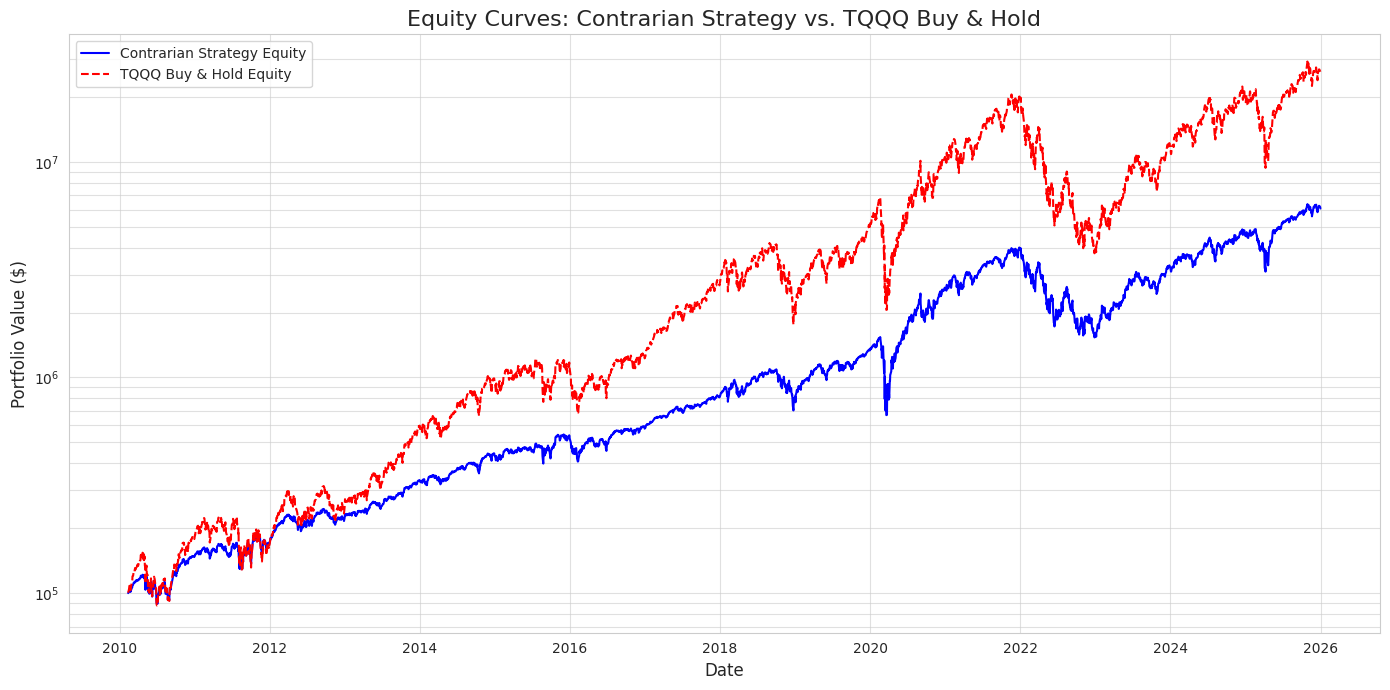

In [92]:
# Plot equity curve for Dynamic Volatility Scalper Strategy
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(simulation_df.index, simulation_df['Strategy_Equity'], label='Contrarian Strategy Equity', color='blue')
plt.plot(simulation_df.index, simulation_df['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curves: Contrarian Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

## Strategy 3: Mean Reversion Strategy based on Logarithmic Trend

In [93]:
# Calculate TQQQ log price, trend line, and residuals
# The regression_df should already be available from previous cells.
# So, we don't need to re-fetch data or create df and then copy to regression_df.

# Calculate the log of TQQQ's price
regression_df['TQQQ_Log_Price'] = np.log(regression_df['TQQQ'])

# Prepare data for linear regression
regression_df['Days_Since_Start'] = np.arange(len(regression_df))

X = regression_df[['Days_Since_Start']]
y = regression_df['TQQQ_Log_Price']

# Perform linear regression
model = LinearRegression()
model.fit(X, y)

# Get the regression line (predicted log prices)
regression_df['TQQQ_Trend_Line'] = model.predict(X)

# Calculate residuals (actual log price - trend line)
regression_df['TQQQ_Residuals'] = regression_df['TQQQ_Log_Price'] - regression_df['TQQQ_Trend_Line']

# Standard_Benchmark_Equity is already calculated in _n2rKaY-ffMu.
# So, we remove the redundant calculation here.

print("Linear Regression Coefficients:")
print(f"  Slope: {model.coef_[0]:.6f}")
print(f"  Intercept: {model.intercept_:.6f}")

# Display the first few rows with the new columns
display(regression_df[['TQQQ', 'TQQQ_Log_Price', 'TQQQ_Trend_Line', 'TQQQ_Residuals', 'Standard_Benchmark_Equity']].head())

Linear Regression Coefficients:
  Slope: 0.001358
  Intercept: -1.290343


Ticker,TQQQ,TQQQ_Log_Price,TQQQ_Trend_Line,TQQQ_Residuals,Standard_Benchmark_Equity
Date,,,,,
2010-02-11,0.206055,-1.579611,-1.290343,-0.289268,100000.000000
2010-02-12,0.206898,-1.575527,-1.288985,-0.286542,100409.216457
2010-02-16,0.214913,-1.537522,-1.287627,-0.249895,104298.700027
2010-02-17,0.218560,-1.520694,-1.286269,-0.234426,106068.664073
2010-02-18,0.222703,-1.501914,-1.284911,-0.217003,108079.492143


Now, let's visualize the log price, the linear regression trend line, and the residuals. This will help us understand the deviations from the trend.

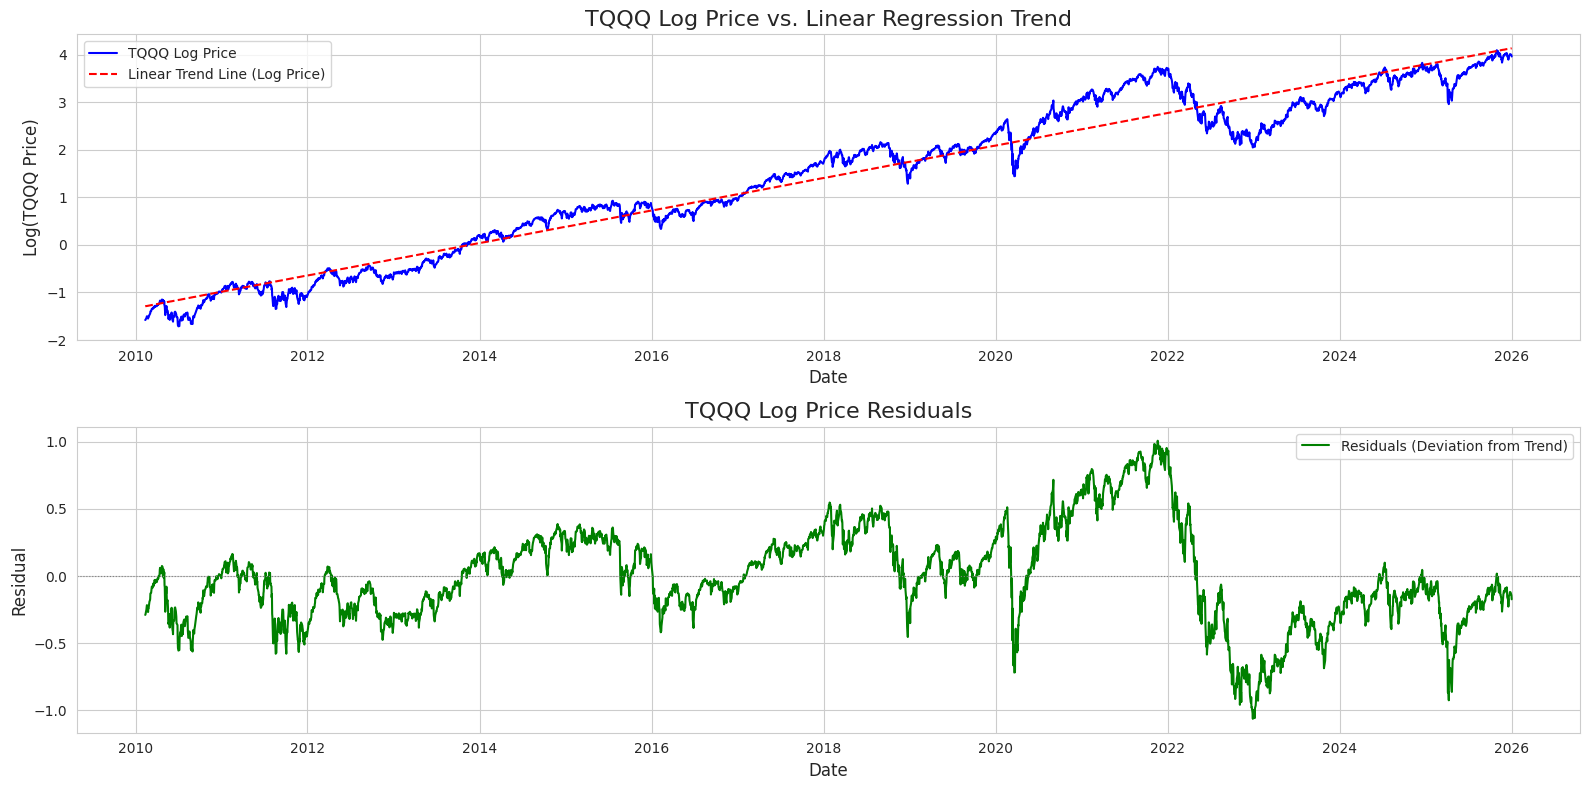

In [94]:
# Plot TQQQ log price, trend, and residuals
plt.figure(figsize=(16, 8))

# Plot Log Price and Trend Line
plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
plt.plot(regression_df.index, regression_df['TQQQ_Log_Price'], label='TQQQ Log Price', color='blue')
plt.plot(regression_df.index, regression_df['TQQQ_Trend_Line'], label='Linear Trend Line (Log Price)', color='red', linestyle='--')
plt.title('TQQQ Log Price vs. Linear Regression Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log(TQQQ Price)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

# Plot Residuals
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
plt.plot(regression_df.index, regression_df['TQQQ_Residuals'], label='Residuals (Deviation from Trend)', color='green')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)
plt.title('TQQQ Log Price Residuals', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residual', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

plt.tight_layout()
plt.show()

The residuals represent how far TQQQ's log price is from its calculated long-term linear trend. A mean reversion strategy would typically involve:

1.  **Going Long (Buying TQQQ):** When the residuals fall significantly below zero, indicating TQQQ is oversold relative to its trend.
2.  **Going Short (Selling TQQQ):** When the residuals rise significantly above zero, indicating TQQQ is overbought relative to its trend.

You would need to define thresholds (e.g., standard deviations of residuals) to trigger these buy/sell signals.

## Mean Reversion Strategy Implementation

In [95]:
# Discover residual regimes using GMM and define allocations
# 1. Fit GMM to TQQQ_Residuals to discover 4 clusters
X_residuals = regression_df['TQQQ_Residuals'].values.reshape(-1, 1)
gmm_residuals = GaussianMixture(n_components=4, random_state=42, covariance_type='full')
raw_labels_residuals = gmm_residuals.fit_predict(X_residuals)

# 2. Sort the discovered regimes strictly by mean residual level
idx_residuals = np.argsort(gmm_residuals.means_.flatten())
state_map_residuals = {old_label: new_label for new_label, old_label in enumerate(idx_residuals)}
regression_df['Residual_Regime'] = [state_map_residuals[label] for label in raw_labels_residuals]

# 3. View the naturally discovered boundaries and mean residual for each regime
boundaries_residuals = regression_df.groupby('Residual_Regime')['TQQQ_Residuals'].agg(['min', 'max', 'mean', 'count'])
print("--- DISCOVERED RESIDUAL REGIMES ---")
print(boundaries_residuals)

# Define allocation based on Residual Regimes (0 = most oversold, 3 = most overbought)
# Example allocation: high allocation for oversold, low/zero for overbought
# Regime 0 (lowest residuals) -> max allocation
# Regime 1 -> moderate allocation
# Regime 2 -> low allocation
# Regime 3 (highest residuals) -> minimal or zero allocation

# We'll map the sorted regimes (0 to 3) to allocation percentages
# For mean reversion, we want to buy when low (regime 0, 1) and sell/reduce when high (regime 2, 3)
# Let's try: 0=100%, 1=75%, 2=25%, 3=0% (or small defensive)

# Note: These allocations are examples and can be tuned.
# 0 = most negative residual (most oversold) -> Buy more
# 1 = moderately negative residual -> Buy some
# 2 = moderately positive residual -> Reduce / sell some
# 3 = most positive residual (most overbought) -> Sell more / stay out

allocation_map = {
    0: 1.0,  # Most oversold: 100% TQQQ
    1: 0.75, # Moderately oversold: 75% TQQQ
    2: 0.25, # Moderately overbought: 25% TQQQ
    3: 0.0   # Most overbought: 0% TQQQ (cash)
}

regression_df['Target_Allocation'] = regression_df['Residual_Regime'].map(allocation_map)

display(regression_df[['TQQQ', 'TQQQ_Log_Price', 'TQQQ_Residuals', 'Residual_Regime', 'Target_Allocation']].head())

--- DISCOVERED RESIDUAL REGIMES ---
                      min       max      mean  count
Residual_Regime                                     
0               -1.063691 -0.453207 -0.655360    316
1               -0.451638  0.024853 -0.179508   1941
2                0.025514  0.455914  0.213830   1346
3                0.456365  1.008557  0.679451    394


Ticker,TQQQ,TQQQ_Log_Price,TQQQ_Residuals,Residual_Regime,Target_Allocation
Date,,,,,
2010-02-11,0.206055,-1.579611,-0.289268,1,0.75
2010-02-12,0.206898,-1.575527,-0.286542,1,0.75
2010-02-16,0.214913,-1.537522,-0.249895,1,0.75
2010-02-17,0.218560,-1.520694,-0.234426,1,0.75
2010-02-18,0.222703,-1.501914,-0.217003,1,0.75


### Backtesting the Residual Mean Reversion Strategy

In [96]:
# Backtest Residual Mean Reversion Strategy
# --- BEGIN: GMM and Target Allocation for Mean Reversion Strategy (moved from f00c774e for robustness) ---
# 1. Fit GMM to TQQQ_Residuals to discover 4 clusters
X_residuals = regression_df['TQQQ_Residuals'].values.reshape(-1, 1)
gmm_residuals = GaussianMixture(n_components=4, random_state=42, covariance_type='full')
raw_labels_residuals = gmm_residuals.fit_predict(X_residuals)

# 2. Sort the discovered regimes strictly by mean residual level
idx_residuals = np.argsort(gmm_residuals.means_.flatten())
state_map_residuals = {old_label: new_label for new_label, old_label in enumerate(idx_residuals)}
regression_df['Residual_Regime'] = [state_map_residuals[label] for label in raw_labels_residuals]

# Define allocation based on Residual Regimes (0 = most oversold, 3 = most overbought)
allocation_map = {
    0: 1.0,  # Most oversold: 100% TQQQ
    1: 0.75, # Moderately oversold: 75% TQQQ
    2: 0.25, # Moderately overbought: 25% TQQQ
    3: 0.0   # Most overbought: 0% TQQQ (cash)
}

regression_df['Target_Allocation'] = regression_df['Residual_Regime'].map(allocation_map)
# --- END: GMM and Target Allocation ---

# Prepare data for backtest
strategy_df = regression_df[['TQQQ', 'TQQQ_Return', 'Target_Allocation']].copy()
# strategy_df['TQQQ_Daily_Return'] = strategy_df['TQQQ'].pct_change() # REMOVE this line
strategy_df['TQQQ_Daily_Return'] = strategy_df['TQQQ_Return'] # Use the already calculated return from regression_df
strategy_df = strategy_df.dropna()

# Shift allocation to reflect decision made *yesterday* for *today's* return
strategy_df['Allocated_Weight'] = strategy_df['Target_Allocation'].shift(1)
strategy_df = strategy_df.dropna()

# Calculate daily strategy returns
strategy_df['Strategy_Daily_Return'] = strategy_df['Allocated_Weight'] * strategy_df['TQQQ_Daily_Return']

# Initial portfolio value
initial_portfolio_value = 100000.0

# Calculate strategy equity curve
strategy_df['Strategy_Equity'] = (1 + strategy_df['Strategy_Daily_Return']).cumprod() * initial_portfolio_value

# Use the Standard_Benchmark_Equity from regression_df, reindexed to strategy_df's dates
strategy_df['Benchmark_Equity'] = regression_df['Standard_Benchmark_Equity'].reindex(strategy_df.index)

# Performance Metrics Calculation
# (Using the same calculate_metrics function from earlier, if defined. If not, redefining it here for robustness.)
def calculate_metrics(return_series, equity_series, initial_value):
    total_return = (equity_series.iloc[-1] / initial_value - 1) * 100
    years = len(equity_series) / 252
    cagr = ((equity_series.iloc[-1] / initial_value) ** (1 / years) - 1) * 100
    ann_vol = return_series.std() * np.sqrt(252) * 100
    sharpe = cagr / ann_vol if ann_vol != 0 else 0

    rolling_max = equity_series.cummax()
    drawdowns = (equity_series - rolling_max) / rolling_max
    max_dd = drawdowns.min() * 100
    return cagr, ann_vol, sharpe, max_dd

strat_cagr, strat_vol, strat_sharpe, strat_mdd = calculate_metrics(
    strategy_df['Strategy_Daily_Return'], strategy_df['Strategy_Equity'], initial_portfolio_value)
bench_cagr, bench_vol, bench_sharpe, bench_mdd = calculate_metrics(
    strategy_df['TQQQ_Daily_Return'], strategy_df['Benchmark_Equity'], initial_portfolio_value)

final_strat_equity = strategy_df['Strategy_Equity'].iloc[-1]
final_bench_equity = strategy_df['Benchmark_Equity'].iloc[-1]

val_strat_str = f"${final_strat_equity:,.2f}"
val_bench_str = f"${final_bench_equity:,.2f}"
cagr_strat_str = f"{strat_cagr:.2f}%"
cagr_bench_str = f"{bench_cagr:.2f}%"
mdd_strat_str = f"{strat_mdd:.2f}%"
mdd_bench_str = f"{bench_mdd:.2f}%"

print(f"\n{'Metric':<25}{'Residual Mean Reversion':<25}{'TQQQ Buy & Hold':<20}")
print("-" * 70)
print(f"{'Ending Portfolio Value':<25}{val_strat_str:<25}{val_bench_str:<20}")
print(f"{'CAGR':<25}{cagr_strat_str:<25}{cagr_bench_str:<20}")
print(f"{'Annualized Vol':<25}{f'{strat_vol:.2f}%':<25}{f'{bench_vol:.2f}%':<20}")
print(f"{'Sharpe Ratio':<25}{f'{strat_sharpe:.2f}':<25}{f'{bench_sharpe:.2f}':<20}")
print(f"{'Max Drawdown':<25}{mdd_strat_str:<25}{mdd_bench_str:<20}")
print("-" * 70)


Metric                   Residual Mean Reversion  TQQQ Buy & Hold     
----------------------------------------------------------------------
Ending Portfolio Value   $27,314,204.67           $25,543,139.23      
CAGR                     42.46%                   41.86%              
Annualized Vol           41.75%                   61.11%              
Sharpe Ratio             1.02                     0.68                
Max Drawdown             -53.01%                  -81.66%             
----------------------------------------------------------------------


### Residual Mean Reversion Strategy Equity Curve

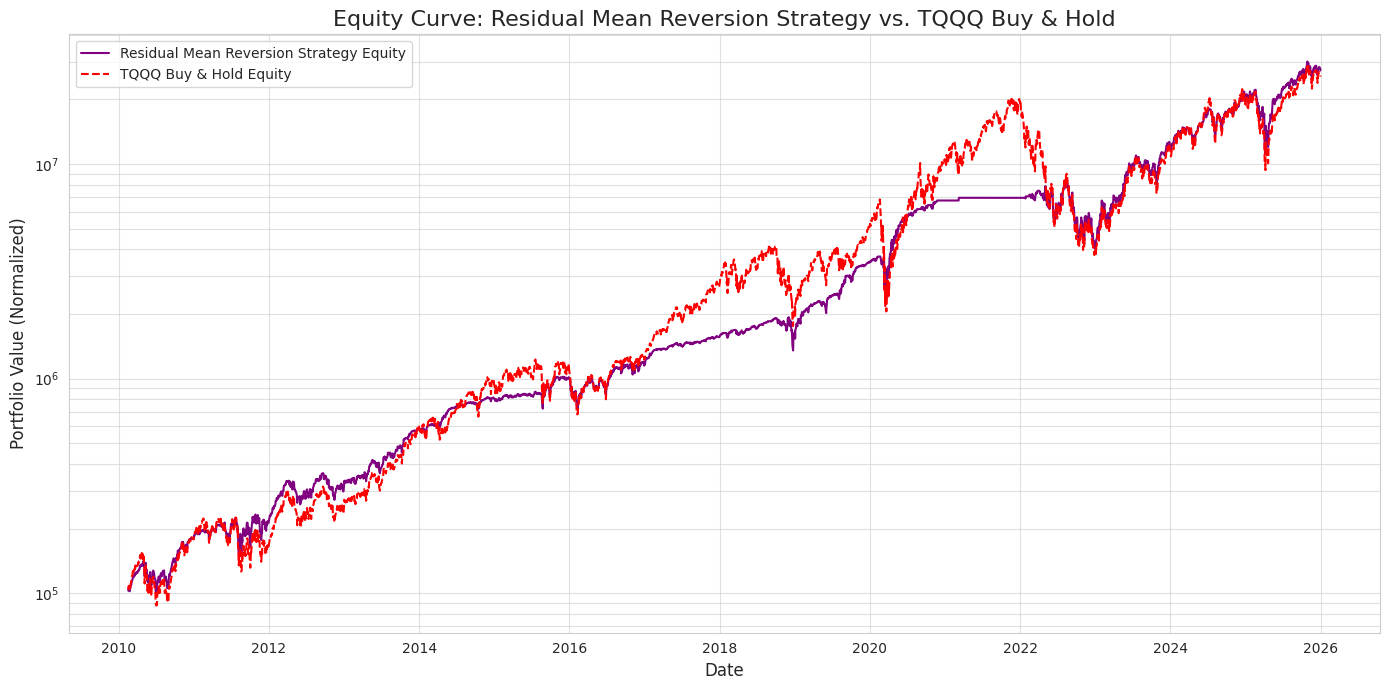

In [97]:
# Plot equity curve for Residual Mean Reversion Strategy
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

plt.plot(strategy_df.index, strategy_df['Strategy_Equity'], label='Residual Mean Reversion Strategy Equity', color='purple')
plt.plot(strategy_df.index, strategy_df['Benchmark_Equity'], label='TQQQ Buy & Hold Equity', color='red', linestyle='--')

plt.title('Equity Curve: Residual Mean Reversion Strategy vs. TQQQ Buy & Hold', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Portfolio Value (Normalized)', fontsize=12)
plt.legend(fontsize=10)
plt.yscale('log') # Use log scale for better visualization of exponential growth
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()